# Proyecto final: modelado y selección

**Autor:** Juan Daniel Barboza  
**Materia:** Series Temporales  
**Etapa 2:** selección del modelo estadístico SARIMA

Este notebook selecciona una configuración SARIMA utilizando exclusivamente `train` y `validation`. El conjunto `test` se mantiene reservado para la comparación final con XGBoost.

## Protocolo de comparación justa

Todas las configuraciones reciben la misma información y se evalúan sobre el mismo horizonte:

- 349 observaciones mensuales para ajuste.
- Los mismos 24 meses para validation.
- Pronóstico multi-step desde un único origen temporal.
- Transformación logarítmica ajustada sin parámetros aprendidos.
- Predicciones devueltas a la escala original antes de calcular RMSE, MAE y MAPE.
- Selección principal por RMSE; MAE y MAPE se reportan como métricas complementarias.

No se comparan ventanas de entrenamiento diferentes y no se consulta test.

In [1]:
from itertools import product
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def locate_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / 'data' / 'Electric_Production.csv').exists():
            return candidate.resolve()
    raise FileNotFoundError('No se encontró data/Electric_Production.csv.')

PROJECT_ROOT = locate_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'Electric_Production.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'Statsmodels: {sm.__version__}')

Raíz del proyecto: C:\Users\jdani\Documents\codex_sandbox\Tareas MScIA\Time Series\Proyecto Final
Statsmodels: 0.14.6


## 1. Carga y reproducción de los cortes

El notebook reproduce las validaciones esenciales de la etapa anterior para que pueda ejecutarse de forma independiente.

In [2]:
raw = pd.read_csv(DATA_PATH)
df = raw.rename(columns={'DATE': 'date', 'IPG2211A2N': 'production'}).copy()
df['date'] = pd.to_datetime(df['date'], errors='raise')
df['production'] = pd.to_numeric(df['production'], errors='raise')
df = df.sort_values('date').set_index('date').asfreq('MS')
series = df['production']

if series.isna().any() or series.index.has_duplicates:
    raise ValueError('La serie contiene faltantes o fechas duplicadas.')
if (series <= 0).any():
    raise ValueError('La transformación logarítmica y MAPE requieren valores positivos.')

VALIDATION_SIZE = 24
TEST_SIZE = 24
train = series.iloc[:-(VALIDATION_SIZE + TEST_SIZE)].copy()
validation = series.iloc[-(VALIDATION_SIZE + TEST_SIZE):-TEST_SIZE].copy()
test = series.iloc[-TEST_SIZE:].copy()

assert len(train) == 349 and len(validation) == 24 and len(test) == 24
assert train.index.max() < validation.index.min() < test.index.min()

pd.DataFrame({
    'observaciones': [len(train), len(validation), len(test)],
    'inicio': [train.index.min(), validation.index.min(), test.index.min()],
    'fin': [train.index.max(), validation.index.max(), test.index.max()],
}, index=['train', 'validation', 'test'])

,observaciones,inicio,fin
train,349,1985-01-01,2014-01-01
validation,24,2014-02-01,2016-01-01
test,24,2016-02-01,2018-01-01


## 2. Referencia estacional ingenua

Antes de seleccionar SARIMA se calcula una referencia mínima. El pronóstico estacional ingenuo repite para cada mes el valor observado 12 meses antes. No cuenta como uno de los dos modelos exigidos por la consigna; sirve para comprobar si SARIMA aporta valor frente a una regla simple.

In [3]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_true - y_pred
    return {
        'RMSE': float(np.sqrt(np.mean(errors ** 2))),
        'MAE': float(np.mean(np.abs(errors))),
        'MAPE_pct': float(np.mean(np.abs(errors / y_true)) * 100),
    }

seasonal_pattern = train.iloc[-12:].to_numpy()
baseline_validation = pd.Series(
    np.tile(seasonal_pattern, int(np.ceil(len(validation) / 12)))[:len(validation)],
    index=validation.index,
    name='naive_estacional',
)
baseline_metrics = regression_metrics(validation, baseline_validation)
pd.Series(baseline_metrics, name='Naive estacional').round(4).to_frame()

,Naive estacional
RMSE,4.0439
MAE,2.8618
MAPE_pct,2.7275


## 3. Estructura temporal de train

La ACF y la PACF se muestran sobre el logaritmo de train después de una diferencia estacional de 12 meses. Se utilizan como diagnóstico y para mantener una grilla pequeña; la configuración final no se elige visualmente, sino por validation.

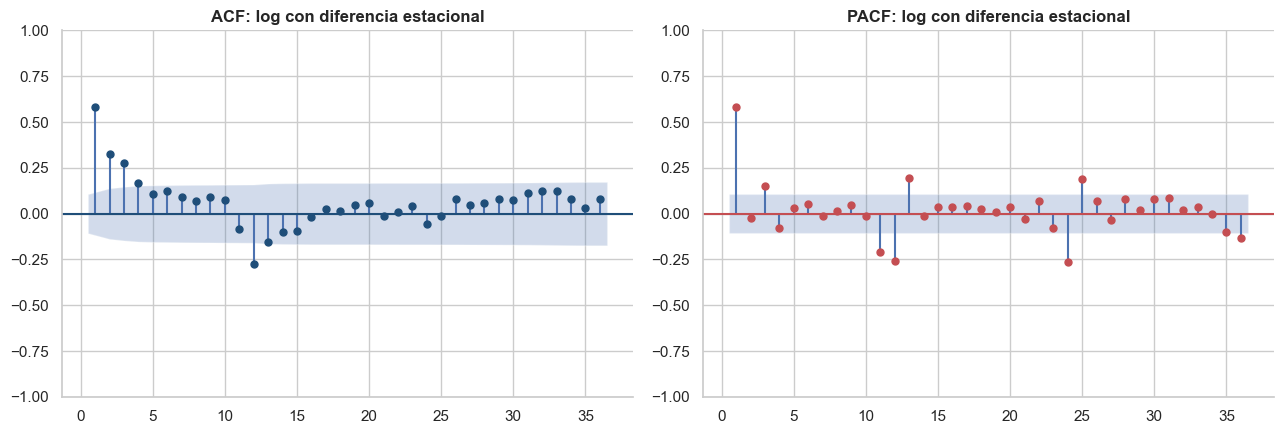

In [4]:
log_train = np.log(train)
seasonal_difference = log_train.diff(12).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(seasonal_difference, lags=36, zero=False, ax=axes[0], color='#1f4e79')
plot_pacf(seasonal_difference, lags=36, zero=False, method='ywm', ax=axes[1], color='#c44e52')
axes[0].set_title('ACF: log con diferencia estacional')
axes[1].set_title('PACF: log con diferencia estacional')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '06_acf_pacf_train.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Búsqueda SARIMA sobre validation

Se evalúan `p` y `q` en `{0, 1, 2}` y `d`, `P`, `D` y `Q` en `{0, 1}`, siempre con período estacional `s = 12`. Esto genera 144 candidatos. La amplitud adicional en los términos no estacionales permite capturar la dependencia corta observada en ACF y PACF sin convertir la búsqueda en una grilla excesiva. Para los modelos sin diferenciación se incluye una constante; en los demás no se agrega tendencia determinista.

Cada candidato se ajusta únicamente con train y produce un pronóstico de 24 pasos. Las configuraciones que fallen o no converjan quedan registradas y no pueden ser seleccionadas.

In [5]:
orders = list(product([0, 1, 2], [0, 1], [0, 1, 2]))
seasonal_terms = list(product([0, 1], [0, 1], [0, 1]))
search_records = []
search_start = time.perf_counter()

for order in orders:
    for seasonal_term in seasonal_terms:
        seasonal_order = (*seasonal_term, 12)
        trend = 'c' if order[1] == 0 and seasonal_term[1] == 0 else 'n'
        record = {
            'order': str(order),
            'seasonal_order': str(seasonal_order),
            'trend': trend,
        }
        fit_start = time.perf_counter()
        try:
            model = SARIMAX(
                log_train,
                order=order,
                seasonal_order=seasonal_order,
                trend=trend,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fitted = model.fit(disp=False, maxiter=200)
            forecast_log = fitted.get_forecast(steps=len(validation)).predicted_mean
            forecast = np.exp(forecast_log.to_numpy())
            metrics = regression_metrics(validation.to_numpy(), forecast)
            record.update({
                **metrics,
                'AIC': float(fitted.aic),
                'BIC': float(fitted.bic),
                'converged': bool(fitted.mle_retvals.get('converged', False)),
                'error': '',
            })
        except Exception as exc:
            record.update({
                'RMSE': np.nan, 'MAE': np.nan, 'MAPE_pct': np.nan,
                'AIC': np.nan, 'BIC': np.nan, 'converged': False,
                'error': f'{type(exc).__name__}: {exc}',
            })
        record['seconds'] = time.perf_counter() - fit_start
        search_records.append(record)

grid_results = pd.DataFrame(search_records)
grid_results.to_csv(RESULTS_DIR / 'sarima_validation_grid.csv', index=False)

eligible = grid_results[
    grid_results['converged'] & grid_results['RMSE'].notna()
].sort_values(['RMSE', 'MAE', 'MAPE_pct']).reset_index(drop=True)
if eligible.empty:
    raise RuntimeError('Ninguna configuración SARIMA convergió correctamente.')

search_summary = pd.Series({
    'candidatos_totales': len(grid_results),
    'candidatos_convergentes': int(grid_results['converged'].sum()),
    'candidatos_con_error': int(grid_results['error'].astype(bool).sum()),
    'tiempo_total_segundos': round(time.perf_counter() - search_start, 2),
}, name='búsqueda')
display(search_summary.to_frame())
display(eligible.head(10).round(4))

,búsqueda
candidatos_totales,144.00
candidatos_convergentes,138.00
candidatos_con_error,0.00
tiempo_total_segundos,139.65


,order,seasonal_order,trend,RMSE,MAE,MAPE_pct,AIC,BIC,converged,error,seconds
0,"(2, 0, 2)","(1, 1, 1, 12)",n,3.0453,2.3011,2.2756,-1487.7058,-1461.2840,True,,5.5721
1,"(2, 0, 2)","(0, 1, 1, 12)",n,3.0762,2.3406,2.3058,-1491.1845,-1468.5372,True,,2.7038
2,"(0, 0, 2)","(1, 1, 1, 12)",n,3.1300,2.3157,2.2317,-1326.8107,-1307.9380,True,,1.2896
3,"(1, 0, 0)","(1, 1, 0, 12)",n,3.1334,2.2972,2.2762,-1385.7164,-1374.3741,True,,0.3775
4,"(0, 0, 2)","(0, 1, 1, 12)",n,3.1546,2.3370,2.2518,-1326.8278,-1311.7296,True,,0.4822
5,"(0, 0, 2)","(1, 1, 0, 12)",n,3.2632,2.4185,2.3283,-1338.4966,-1323.3613,True,,0.4612
6,"(2, 0, 0)","(1, 1, 0, 12)",n,3.2677,2.3915,2.3751,-1380.6530,-1365.5424,True,,0.5683
7,"(2, 0, 1)","(0, 1, 1, 12)",n,3.3162,2.4749,2.4519,-1380.2369,-1361.3487,True,,1.1371
8,"(2, 0, 2)","(1, 1, 0, 12)",n,3.3500,2.4109,2.3591,-1412.4151,-1389.7491,True,,2.0881
9,"(1, 0, 2)","(1, 1, 1, 12)",n,3.3598,2.6608,2.6345,-1480.2251,-1457.5778,True,,1.6972


## 5. Configuración seleccionada y comparación

La primera fila de la tabla anterior minimiza RMSE en validation. Se reajusta esa misma configuración sobre train para obtener predicciones, intervalos y diagnósticos reproducibles.

In [6]:
best_row = eligible.iloc[0]
best_order = tuple(int(value) for value in best_row['order'].strip('()').split(','))
best_seasonal_order = tuple(
    int(value) for value in best_row['seasonal_order'].strip('()').split(',')
)
best_trend = best_row['trend']

best_model = SARIMAX(
    log_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend=best_trend,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
best_fit = best_model.fit(disp=False, maxiter=200)
forecast_result = best_fit.get_forecast(steps=len(validation))
best_forecast = pd.Series(
    np.exp(forecast_result.predicted_mean.to_numpy()),
    index=validation.index,
    name='SARIMA',
)
log_interval = forecast_result.conf_int(alpha=0.05)
lower_interval = np.exp(log_interval.iloc[:, 0].to_numpy())
upper_interval = np.exp(log_interval.iloc[:, 1].to_numpy())
sarima_metrics = regression_metrics(validation, best_forecast)

validation_comparison = pd.DataFrame([
    {'modelo': 'Naive estacional', **baseline_metrics},
    {'modelo': 'SARIMA', **sarima_metrics},
]).set_index('modelo').sort_values('RMSE')
validation_comparison.to_csv(RESULTS_DIR / 'sarima_validation_metrics.csv')

selected_config = pd.DataFrame([{
    'order': str(best_order),
    'seasonal_order': str(best_seasonal_order),
    'trend': best_trend,
    **sarima_metrics,
    'AIC_train': float(best_fit.aic),
    'BIC_train': float(best_fit.bic),
}])
selected_config.to_csv(RESULTS_DIR / 'sarima_selected_config.csv', index=False)

display(selected_config.round(4))
display(validation_comparison.round(4))

,order,seasonal_order,trend,RMSE,MAE,MAPE_pct,AIC_train,BIC_train
0,"(2, 0, 2)","(1, 1, 1, 12)",n,3.0453,2.3011,2.2756,-1487.7058,-1461.284


,RMSE,MAE,MAPE_pct
modelo,,,
SARIMA,3.0453,2.3011,2.2756
Naive estacional,4.0439,2.8618,2.7275


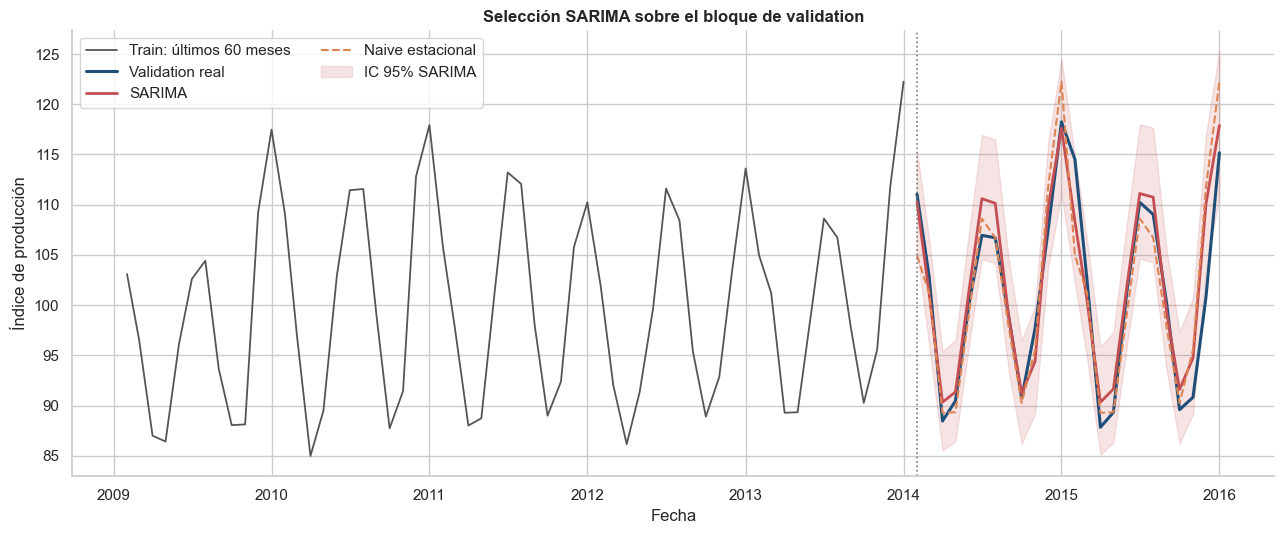

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train.iloc[-60:], color='#555555', linewidth=1.3, label='Train: últimos 60 meses')
ax.plot(validation, color='#1f4e79', linewidth=2.2, label='Validation real')
ax.plot(best_forecast, color='#c44e52', linewidth=2, label='SARIMA')
ax.plot(baseline_validation, color='#dd8452', linestyle='--', linewidth=1.5, label='Naive estacional')
ax.fill_between(
    validation.index, lower_interval, upper_interval,
    color='#c44e52', alpha=0.15, label='IC 95% SARIMA',
)
ax.axvline(validation.index.min(), color='#777777', linestyle=':', linewidth=1.2)
ax.set(
    title='Selección SARIMA sobre el bloque de validation',
    xlabel='Fecha',
    ylabel='Índice de producción',
)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '07_sarima_validation.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Diagnóstico provisional de residuales

Los residuales de ajuste se analizan en escala logarítmica. Se descarta un período inicial de 24 meses para reducir el efecto de inicialización. La prueba de Ljung-Box contrasta autocorrelación conjunta: valores p pequeños indican estructura temporal que el modelo todavía no capturó. Este diagnóstico es provisional; el análisis final se repetirá después de comparar ambos modelos sobre test.

,lb_stat,lb_pvalue
12,8.4631,0.7480
24,27.6388,0.2756


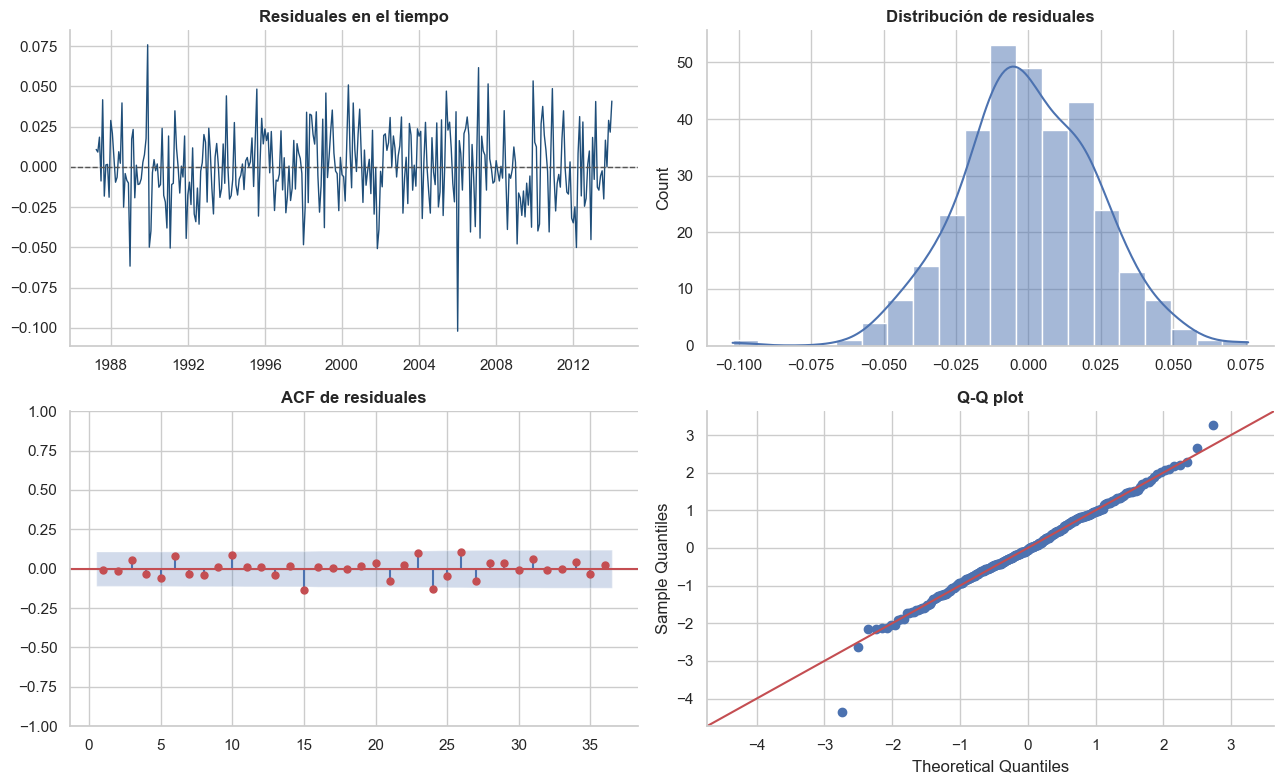

In [8]:
burn_in = max(24, int(getattr(best_fit, 'loglikelihood_burn', 0)))
residuals = pd.Series(best_fit.resid, index=train.index).iloc[burn_in:].dropna()
ljung_box = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
display(ljung_box.round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(residuals, color='#1f4e79', linewidth=1)
axes[0, 0].axhline(0, color='#555555', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuales en el tiempo')
sns.histplot(residuals, kde=True, color='#4c72b0', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de residuales')
plot_acf(residuals, lags=36, zero=False, color='#c44e52', ax=axes[1, 0])
axes[1, 0].set_title('ACF de residuales')
sm.qqplot(residuals, line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title('Q-Q plot')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '08_sarima_residuales_train.png', dpi=180, bbox_inches='tight')
plt.show()

## Conclusiones y punto de control de la etapa SARIMA

1. Se evaluaron 144 configuraciones sobre exactamente los mismos 24 meses de validation. Convergieron 138 y ninguna terminó con error de ejecución.
2. La configuración seleccionada por RMSE fue `SARIMA(2,0,2)(1,1,1,12)` sin tendencia determinista.
3. En validation obtuvo RMSE `3,0453`, MAE `2,3011` y MAPE `2,2756 %`.
4. Frente a la referencia estacional, redujo RMSE en `24,69 %`, MAE en `19,59 %` y MAPE en `16,57 %`. Por lo tanto, aporta valor predictivo frente a repetir el último ciclo anual.
5. Ljung-Box produjo valores p de `0,7480` a 12 meses y `0,2756` a 24 meses. No hay evidencia de autocorrelación residual conjunta en esos horizontes.
6. La distribución residual es aproximadamente centrada y el Q-Q plot es mayormente lineal, aunque conserva algunos valores extremos en las colas.
7. Test continúa reservado. XGBoost deberá utilizar los mismos cortes, transformación, horizonte y métricas antes de cualquier evaluación final.

# XGBoost: modelo de Machine Learning

XGBoost no incorpora el orden temporal automáticamente. La serie se convierte en una tabla supervisada con variables construidas exclusivamente a partir del pasado. El modelo se selecciona sobre el mismo bloque de validation de 24 meses y mediante un pronóstico recursivo desde el mismo origen temporal que SARIMA.

## 7. Ingeniería de variables sin fuga temporal

Las variables utilizadas son:

- Rezagos de 1, 2, 3, 6, 12, 13 y 24 meses.
- Media y desviación móvil de 3, 6 y 12 meses.
- Mes del año codificado con seno y coseno para representar su naturaleza cíclica.

Todas las estadísticas móviles usan `shift(1)`: el valor del mes que se desea predecir nunca forma parte de sus propias variables.

In [9]:
from xgboost import XGBRegressor
import xgboost as xgb

LAGS = [1, 2, 3, 6, 12, 13, 24]
ROLLING_WINDOWS = [3, 6, 12]

def build_supervised_table(log_values):
    table = pd.DataFrame({'target': log_values})
    for lag in LAGS:
        table[f'lag_{lag}'] = log_values.shift(lag)
    shifted = log_values.shift(1)
    for window in ROLLING_WINDOWS:
        table[f'rolling_mean_{window}'] = shifted.rolling(window).mean()
        table[f'rolling_std_{window}'] = shifted.rolling(window).std(ddof=0)
    month = table.index.month
    table['month_sin'] = np.sin(2 * np.pi * month / 12)
    table['month_cos'] = np.cos(2 * np.pi * month / 12)
    return table.dropna()

training_table = build_supervised_table(log_train)
X_train = training_table.drop(columns='target')
y_train = training_table['target']
FEATURE_COLUMNS = X_train.columns.tolist()

feature_summary = pd.Series({
    'xgboost_version': xgb.__version__,
    'filas_disponibles_train': len(X_train),
    'variables_predictoras': X_train.shape[1],
    'primera_fecha_entrenable': X_train.index.min().date(),
    'ultima_fecha_entrenable': X_train.index.max().date(),
}, name='XGBoost')
display(feature_summary.to_frame())
display(X_train.head(3).round(4))

,XGBoost
xgboost_version,3.2.0
filas_disponibles_train,325
variables_predictoras,15
primera_fecha_entrenable,1987-01-01
ultima_fecha_entrenable,2014-01-01


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_13,lag_24,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month_sin,month_cos
date,,,,,,,,,,,,,,,
1987-01-01,4.2093,4.0709,4.0402,4.1732,4.2822,4.2172,4.2710,4.1068,0.0736,4.1243,0.0593,4.1229,0.0799,0.500,0.866
1987-02-01,4.2892,4.2093,4.0709,4.1539,4.2069,4.2822,4.2455,4.1898,0.0902,4.1437,0.0853,4.1234,0.0811,0.866,0.500
1987-03-01,4.2371,4.2892,4.2093,4.0987,4.1184,4.2069,4.1220,4.2452,0.0331,4.1575,0.0923,4.1260,0.0841,1.000,0.000


## 8. Pronóstico recursivo multi-step

Para pronosticar 24 meses desde enero de 2014, solo el primer mes puede usar directamente todos los valores reales anteriores. Después, cada predicción se agrega a la historia y se utiliza para construir los rezagos del mes siguiente. Así se reproduce un escenario real de pronóstico a 24 pasos y se evita utilizar los valores observados de validation como entradas.

In [10]:
def feature_row_from_history(history, forecast_date):
    row = {}
    for lag in LAGS:
        row[f'lag_{lag}'] = float(history.iloc[-lag])
    for window in ROLLING_WINDOWS:
        recent = history.iloc[-window:]
        row[f'rolling_mean_{window}'] = float(recent.mean())
        row[f'rolling_std_{window}'] = float(recent.std(ddof=0))
    month = forecast_date.month
    row['month_sin'] = np.sin(2 * np.pi * month / 12)
    row['month_cos'] = np.cos(2 * np.pi * month / 12)
    return pd.DataFrame([row], index=[forecast_date])[FEATURE_COLUMNS]

def recursive_xgboost_forecast(model, log_history, forecast_index):
    history = log_history.copy()
    predictions_log = []
    for forecast_date in forecast_index:
        row = feature_row_from_history(history, forecast_date)
        prediction_log = float(model.predict(row)[0])
        predictions_log.append(prediction_log)
        history.loc[forecast_date] = prediction_log
    return pd.Series(
        np.exp(predictions_log), index=forecast_index, name='XGBoost'
    )

print('Función recursiva preparada; validation todavía no se usa para ajustar el modelo.')

Función recursiva preparada; validation todavía no se usa para ajustar el modelo.


## 9. Búsqueda de hiperparámetros sobre validation

Se prueban 64 combinaciones pequeñas de cantidad de árboles, profundidad, tasa de aprendizaje, peso mínimo por nodo y fracciones de filas y columnas. Cada modelo se ajusta con las mismas 325 filas supervisadas de train y produce los mismos 24 meses mediante la función recursiva. No se usa *early stopping* con validation porque eso convertiría el bloque de selección en parte del entrenamiento.

In [11]:
xgb_parameter_grid = list(product(
    [200, 400],
    [0.03, 0.05],
    [2, 3],
    [1, 5],
    [0.8, 1.0],
    [0.8, 1.0],
))
xgb_search_records = []
xgb_search_start = time.perf_counter()

for values in xgb_parameter_grid:
    params = dict(zip(
        ['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight',
         'subsample', 'colsample_bytree'],
        values,
    ))
    record = params.copy()
    fit_start = time.perf_counter()
    try:
        model = XGBRegressor(
            **params,
            objective='reg:squarederror',
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method='hist',
            random_state=SEED,
            n_jobs=2,
            verbosity=0,
        )
        model.fit(X_train, y_train)
        forecast = recursive_xgboost_forecast(model, log_train, validation.index)
        record.update({
            **regression_metrics(validation, forecast),
            'error': '',
        })
    except Exception as exc:
        record.update({
            'RMSE': np.nan, 'MAE': np.nan, 'MAPE_pct': np.nan,
            'error': f'{type(exc).__name__}: {exc}',
        })
    record['seconds'] = time.perf_counter() - fit_start
    xgb_search_records.append(record)

xgb_grid_results = pd.DataFrame(xgb_search_records)
xgb_grid_results.to_csv(RESULTS_DIR / 'xgboost_validation_grid.csv', index=False)
xgb_eligible = xgb_grid_results[
    xgb_grid_results['error'].eq('') & xgb_grid_results['RMSE'].notna()
].sort_values(['RMSE', 'MAE', 'MAPE_pct']).reset_index(drop=True)
if xgb_eligible.empty:
    raise RuntimeError('Ninguna configuración XGBoost pudo evaluarse.')

xgb_search_summary = pd.Series({
    'candidatos_totales': len(xgb_grid_results),
    'candidatos_validos': len(xgb_eligible),
    'candidatos_con_error': int(xgb_grid_results['error'].astype(bool).sum()),
    'tiempo_total_segundos': round(time.perf_counter() - xgb_search_start, 2),
}, name='búsqueda XGBoost')
display(xgb_search_summary.to_frame())
display(xgb_eligible.head(10).round(4))

,búsqueda XGBoost
candidatos_totales,64.00
candidatos_validos,64.00
candidatos_con_error,0.00
tiempo_total_segundos,12.74


,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,RMSE,MAE,MAPE_pct,error,seconds
0,200,0.03,3,1,0.8,0.8,3.8818,2.7852,2.7083,,0.1742
1,400,0.03,2,1,1.0,0.8,3.9187,2.7731,2.6940,,0.1843
2,400,0.03,2,5,1.0,0.8,3.9672,2.7792,2.7021,,0.1693
3,200,0.05,2,1,0.8,1.0,3.9680,2.8450,2.7559,,0.1333
4,200,0.03,2,1,0.8,0.8,3.9686,3.0012,2.9046,,0.1618
5,200,0.03,3,1,0.8,1.0,3.9757,2.8936,2.8018,,0.1744
6,200,0.03,2,5,0.8,0.8,3.9780,3.0200,2.9197,,0.1269
7,200,0.05,2,5,1.0,1.0,3.9965,2.7538,2.6451,,0.1379
8,200,0.03,2,5,1.0,0.8,4.0041,3.0014,2.8995,,0.2067
9,200,0.03,2,1,1.0,0.8,4.0110,3.0612,2.9561,,0.1443


## 10. Configuración seleccionada y comparación de modelos

La configuración con menor RMSE se reajusta sobre train. La comparación incluye la referencia, SARIMA y XGBoost sobre exactamente las mismas observaciones de validation.

In [12]:
best_xgb_row = xgb_eligible.iloc[0]
best_xgb_params = {
    'n_estimators': int(best_xgb_row['n_estimators']),
    'learning_rate': float(best_xgb_row['learning_rate']),
    'max_depth': int(best_xgb_row['max_depth']),
    'min_child_weight': int(best_xgb_row['min_child_weight']),
    'subsample': float(best_xgb_row['subsample']),
    'colsample_bytree': float(best_xgb_row['colsample_bytree']),
}
best_xgb_model = XGBRegressor(
    **best_xgb_params,
    objective='reg:squarederror',
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method='hist',
    random_state=SEED,
    n_jobs=2,
    verbosity=0,
)
best_xgb_model.fit(X_train, y_train)
xgb_validation_forecast = recursive_xgboost_forecast(
    best_xgb_model, log_train, validation.index
)
xgb_metrics = regression_metrics(validation, xgb_validation_forecast)

validation_model_comparison = pd.DataFrame([
    {'modelo': 'Naive estacional', **baseline_metrics},
    {'modelo': 'SARIMA', **sarima_metrics},
    {'modelo': 'XGBoost', **xgb_metrics},
]).set_index('modelo').sort_values('RMSE')
validation_model_comparison.to_csv(RESULTS_DIR / 'validation_model_comparison.csv')

xgb_selected_config = pd.DataFrame([{**best_xgb_params, **xgb_metrics}])
xgb_selected_config.to_csv(RESULTS_DIR / 'xgboost_selected_config.csv', index=False)
display(xgb_selected_config.round(4))
display(validation_model_comparison.round(4))

,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,RMSE,MAE,MAPE_pct
0,200,0.03,3,1,0.8,0.8,3.8818,2.7852,2.7083


,RMSE,MAE,MAPE_pct
modelo,,,
SARIMA,3.0453,2.3011,2.2756
XGBoost,3.8818,2.7852,2.7083
Naive estacional,4.0439,2.8618,2.7275


,importancia
lag_24,0.4984
lag_12,0.2927
lag_6,0.1162
lag_1,0.0177
month_cos,0.0132
lag_13,0.0089
rolling_std_3,0.0077
rolling_std_6,0.0075
lag_2,0.0075
rolling_std_12,0.0060


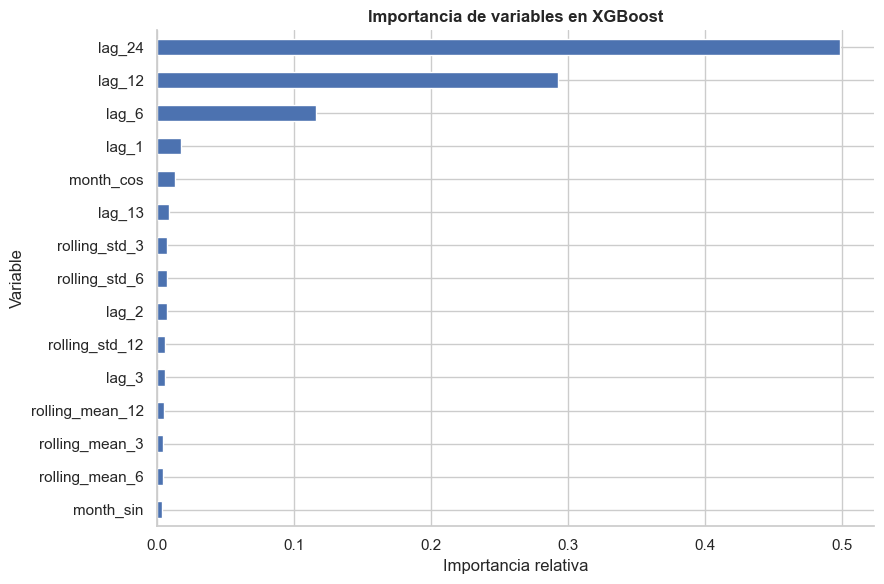

In [13]:
feature_importance = pd.Series(
    best_xgb_model.feature_importances_, index=FEATURE_COLUMNS, name='importancia'
).sort_values(ascending=True)
display(feature_importance.sort_values(ascending=False).round(4).to_frame())

fig, ax = plt.subplots(figsize=(9, 6))
feature_importance.plot.barh(color='#4c72b0', ax=ax)
ax.set(
    title='Importancia de variables en XGBoost',
    xlabel='Importancia relativa',
    ylabel='Variable',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '09_xgboost_importancia.png', dpi=180, bbox_inches='tight')
plt.show()

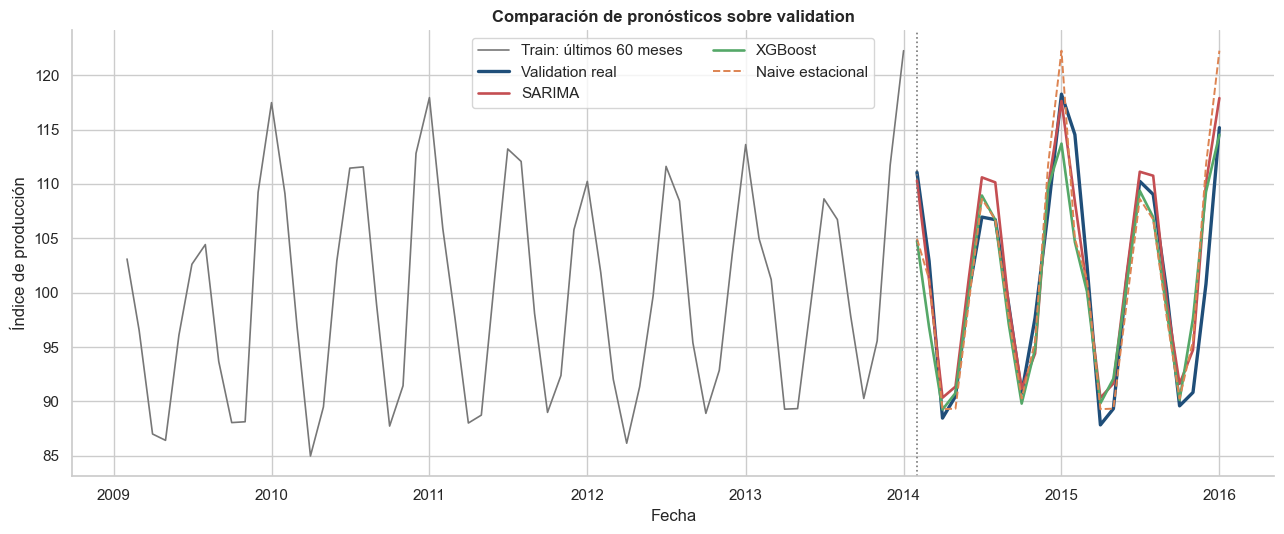

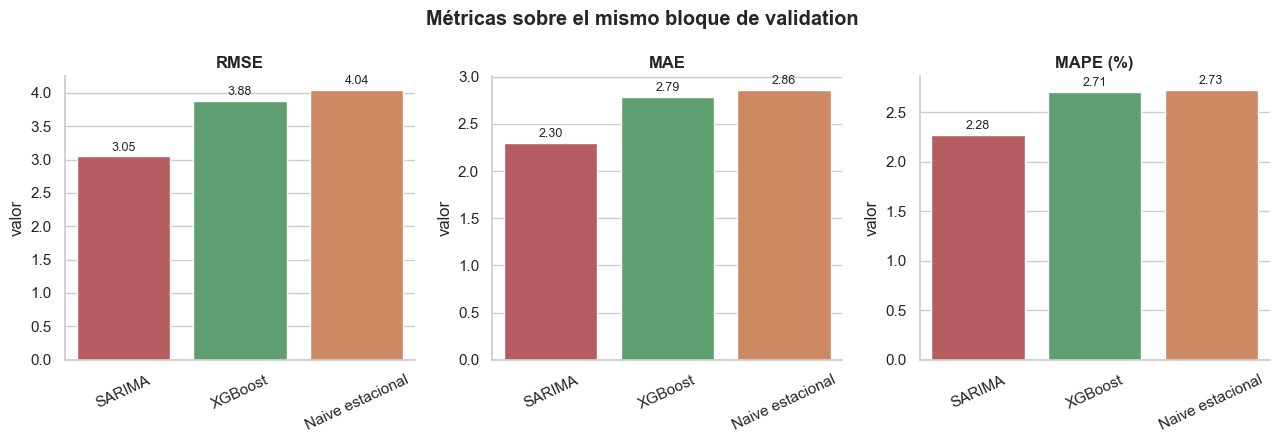

In [14]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train.iloc[-60:], color='#777777', linewidth=1.2, label='Train: últimos 60 meses')
ax.plot(validation, color='#1f4e79', linewidth=2.4, label='Validation real')
ax.plot(best_forecast, color='#c44e52', linewidth=1.9, label='SARIMA')
ax.plot(xgb_validation_forecast, color='#55a868', linewidth=1.9, label='XGBoost')
ax.plot(baseline_validation, color='#dd8452', linestyle='--', linewidth=1.4, label='Naive estacional')
ax.axvline(validation.index.min(), color='#777777', linestyle=':', linewidth=1.2)
ax.set(
    title='Comparación de pronósticos sobre validation',
    xlabel='Fecha',
    ylabel='Índice de producción',
)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '10_modelos_validation.png', dpi=180, bbox_inches='tight')
plt.show()

metrics_long = validation_model_comparison.reset_index().melt(
    id_vars='modelo', var_name='métrica', value_name='valor'
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
palette = {'Naive estacional': '#dd8452', 'SARIMA': '#c44e52', 'XGBoost': '#55a868'}
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE_pct']):
    subset = metrics_long[metrics_long['métrica'] == metric]
    sns.barplot(data=subset, x='modelo', y='valor', hue='modelo', palette=palette, legend=False, ax=ax)
    ax.set_title(metric.replace('_pct', ' (%)'))
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=9)
fig.suptitle('Métricas sobre el mismo bloque de validation', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '11_metricas_validation.png', dpi=180, bbox_inches='tight')
plt.show()

## 11. Errores de pronóstico de XGBoost en validation

Con 24 observaciones, este análisis es provisional. Se inspeccionan los errores multi-step, su distribución, ACF y Q-Q plot. El diagnóstico comparable y definitivo para ambos modelos se realizará sobre test después de cerrar todas las decisiones.

,lb_stat,lb_pvalue
6,6.6573,0.3537
12,18.4501,0.1027


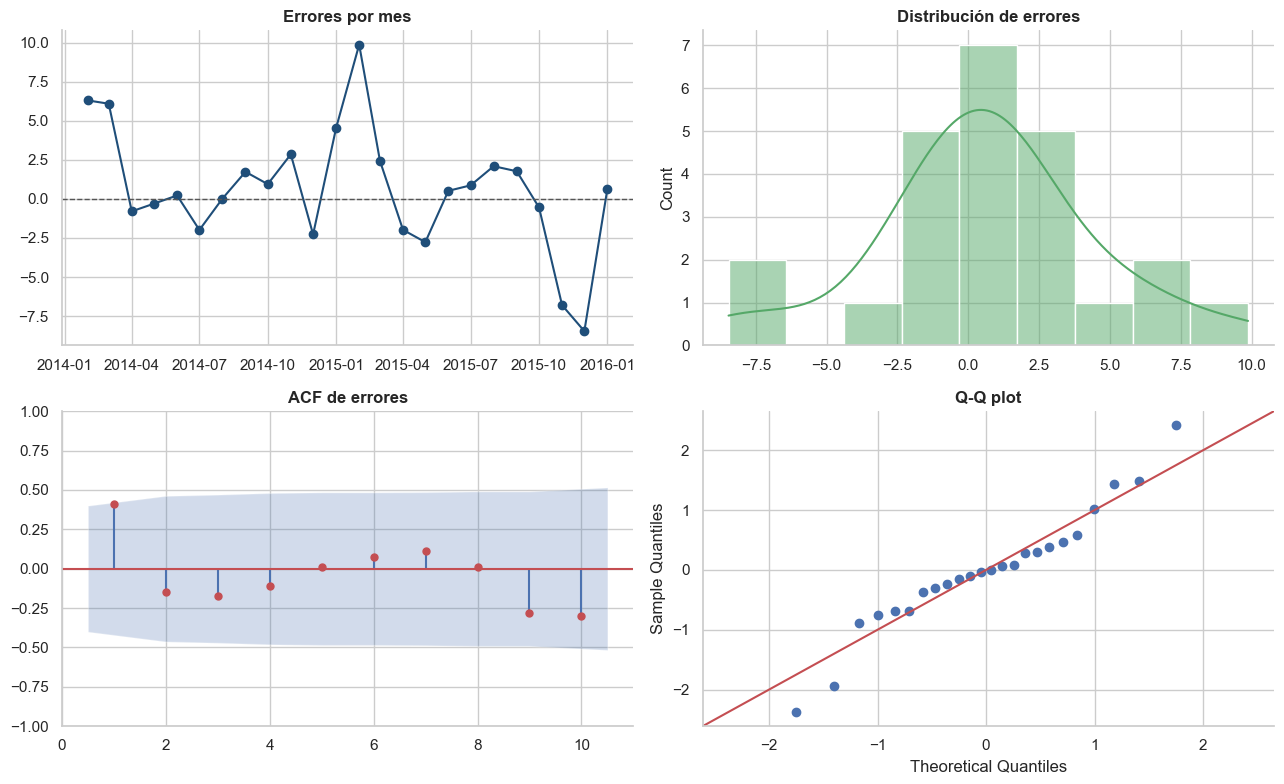

In [15]:
xgb_validation_errors = validation - xgb_validation_forecast
xgb_ljung_box = acorr_ljungbox(xgb_validation_errors, lags=[6, 12], return_df=True)
display(xgb_ljung_box.round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(xgb_validation_errors, marker='o', color='#1f4e79')
axes[0, 0].axhline(0, color='#555555', linestyle='--', linewidth=1)
axes[0, 0].set_title('Errores por mes')
sns.histplot(xgb_validation_errors, kde=True, color='#55a868', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de errores')
plot_acf(xgb_validation_errors, lags=10, zero=False, color='#c44e52', ax=axes[1, 0])
axes[1, 0].set_title('ACF de errores')
sm.qqplot(xgb_validation_errors, line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title('Q-Q plot')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '12_xgboost_errores_validation.png', dpi=180, bbox_inches='tight')
plt.show()

## Conclusiones y punto de control antes de test

1. Se evaluaron 64 configuraciones XGBoost; todas se ajustaron y evaluaron correctamente sobre los mismos 24 meses de validation.
2. La configuración seleccionada usa 200 árboles, `learning_rate=0,03`, profundidad 3, `min_child_weight=1`, `subsample=0,8` y `colsample_bytree=0,8`.
3. XGBoost obtuvo RMSE `3,8818`, MAE `2,7852` y MAPE `2,7083 %`. Frente a la referencia estacional redujo RMSE en `4,01 %`, MAE en `2,68 %` y MAPE en `0,70 %`.
4. SARIMA continúa siendo el mejor modelo en validation: su RMSE es `21,55 %` menor, su MAE `17,38 %` menor y su MAPE `15,98 %` menor que los de XGBoost.
5. Los rezagos de 24, 12 y 6 meses reúnen aproximadamente `90,7 %` de la importancia del modelo. Esto confirma que el patrón estacional y la memoria de largo plazo dominan el pronóstico.
6. Ljung-Box sobre los 24 errores de validation produjo valores p de `0,3537` a 6 meses y `0,1027` a 12 meses. No hay evidencia significativa de autocorrelación, aunque el tamaño de muestra es pequeño y el diagnóstico es provisional.
7. La gráfica muestra que XGBoost sigue la forma estacional, pero tiende a suavizar algunos máximos y mínimos, lo que explica su desventaja frente a SARIMA.
8. Las configuraciones de ambos modelos quedan fijadas. Test todavía no se usa; el siguiente paso será reentrenar cada modelo con train + validation y abrir test una sola vez para la evaluación final.

# Evaluación final sobre test

Las configuraciones se fijaron exclusivamente con validation. En esta etapa cada modelo se reentrena una sola vez con `train + validation` (373 meses) y se evalúa sobre los mismos 24 meses de test. No se ajustan hiperparámetros ni se cambia el modelo a partir de estos resultados.

## 12. Reentrenamiento con train + validation y pronóstico final

In [16]:
development = pd.concat([train, validation])
log_development = np.log(development)
assert len(development) == 373
assert development.index.max() < test.index.min()

# La referencia también incorpora toda la información disponible antes de test.
baseline_test = pd.Series(
    np.tile(development.iloc[-12:].to_numpy(), 2)[:len(test)],
    index=test.index,
    name='Naive estacional',
)

final_sarima_model = SARIMAX(
    log_development,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend=best_trend,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_sarima_fit = final_sarima_model.fit(disp=False, maxiter=200)
final_sarima_result = final_sarima_fit.get_forecast(steps=len(test))
sarima_test_forecast = pd.Series(
    np.exp(final_sarima_result.predicted_mean.to_numpy()),
    index=test.index,
    name='SARIMA',
)
final_log_interval = final_sarima_result.conf_int(alpha=0.05)
sarima_test_lower = np.exp(final_log_interval.iloc[:, 0].to_numpy())
sarima_test_upper = np.exp(final_log_interval.iloc[:, 1].to_numpy())

development_table = build_supervised_table(log_development)
X_development = development_table.drop(columns='target')
y_development = development_table['target']
assert X_development.columns.tolist() == FEATURE_COLUMNS

final_xgb_model = XGBRegressor(
    **best_xgb_params,
    objective='reg:squarederror',
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method='hist',
    random_state=SEED,
    n_jobs=2,
    verbosity=0,
)
final_xgb_model.fit(X_development, y_development)
xgb_test_forecast = recursive_xgboost_forecast(
    final_xgb_model, log_development, test.index
)

test_predictions = pd.concat(
    [test.rename('Real'), baseline_test, sarima_test_forecast, xgb_test_forecast],
    axis=1,
)
if test_predictions.isna().any().any():
    raise RuntimeError('El pronóstico final contiene valores faltantes.')

test_model_comparison = pd.DataFrame([
    {'modelo': 'Naive estacional', **regression_metrics(test, baseline_test)},
    {'modelo': 'SARIMA', **regression_metrics(test, sarima_test_forecast)},
    {'modelo': 'XGBoost', **regression_metrics(test, xgb_test_forecast)},
]).set_index('modelo').sort_values('RMSE')

test_predictions.index.name = 'date'
test_predictions.to_csv(RESULTS_DIR / 'test_predictions.csv')
test_model_comparison.to_csv(RESULTS_DIR / 'test_model_comparison.csv')

final_training_summary = pd.DataFrame([
    {
        'modelo': 'SARIMA',
        'categoria': 'Estadístico',
        'observaciones_desarrollo': len(development),
        'configuracion': f'{best_order} x {best_seasonal_order}; trend={best_trend}',
    },
    {
        'modelo': 'XGBoost',
        'categoria': 'Machine Learning',
        'observaciones_desarrollo': len(X_development),
        'configuracion': str(best_xgb_params),
    },
]).set_index('modelo')
final_training_summary.to_csv(RESULTS_DIR / 'final_training_summary.csv')

display(final_training_summary)
display(test_model_comparison.round(4))
display(test_predictions.round(4))

,categoria,observaciones_desarrollo,configuracion
modelo,,,
SARIMA,Estadístico,373,"(2, 0, 2) x (1, 1, 1, 12); trend=n"
XGBoost,Machine Learning,349,"{'n_estimators': 200, 'learning_rate': 0.03, '..."


,RMSE,MAE,MAPE_pct
modelo,,,
SARIMA,4.3207,3.3861,3.3093
XGBoost,6.0292,4.4115,4.2640
Naive estacional,6.4774,4.3429,4.1548


,Real,Naive estacional,SARIMA,XGBoost
date,,,,
2016-02-01,104.3867,114.5313,108.8621,113.4411
2016-03-01,92.8193,102.5268,100.5452,105.5542
2016-04-01,86.8332,87.8375,89.1273,89.1739
2016-05-01,88.1173,89.3233,90.5854,90.1978
2016-06-01,101.8580,101.3074,101.0594,100.5813
2016-07-01,112.4730,110.2382,109.9445,108.7348
2016-08-01,113.7736,109.0313,109.4692,107.8831
2016-09-01,100.7214,100.2091,99.1078,100.2119
2016-10-01,89.5034,89.5857,90.7380,89.0296


## 13. Pronósticos y comparación final de métricas

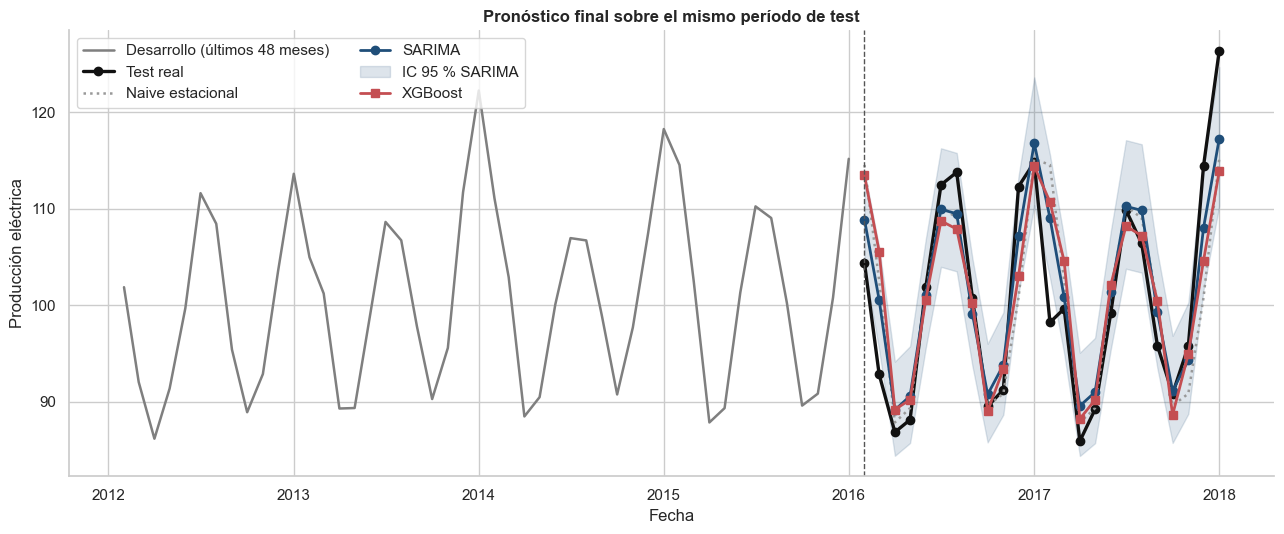

In [17]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(development.iloc[-48:], color='#7f7f7f', linewidth=1.8, label='Desarrollo (últimos 48 meses)')
ax.plot(test, color='#111111', marker='o', linewidth=2.4, label='Test real')
ax.plot(baseline_test, color='#999999', linestyle=':', linewidth=1.8, label='Naive estacional')
ax.plot(sarima_test_forecast, color='#1f4e79', marker='o', linewidth=2, label='SARIMA')
ax.fill_between(
    test.index, sarima_test_lower, sarima_test_upper,
    color='#1f4e79', alpha=0.15, label='IC 95 % SARIMA',
)
ax.plot(xgb_test_forecast, color='#c44e52', marker='s', linewidth=2, label='XGBoost')
ax.axvline(test.index.min(), color='#555555', linestyle='--', linewidth=1)
ax.set_title('Pronóstico final sobre el mismo período de test')
ax.set_xlabel('Fecha')
ax.set_ylabel('Producción eléctrica')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '13_pronosticos_test.png', dpi=180, bbox_inches='tight')
plt.show()

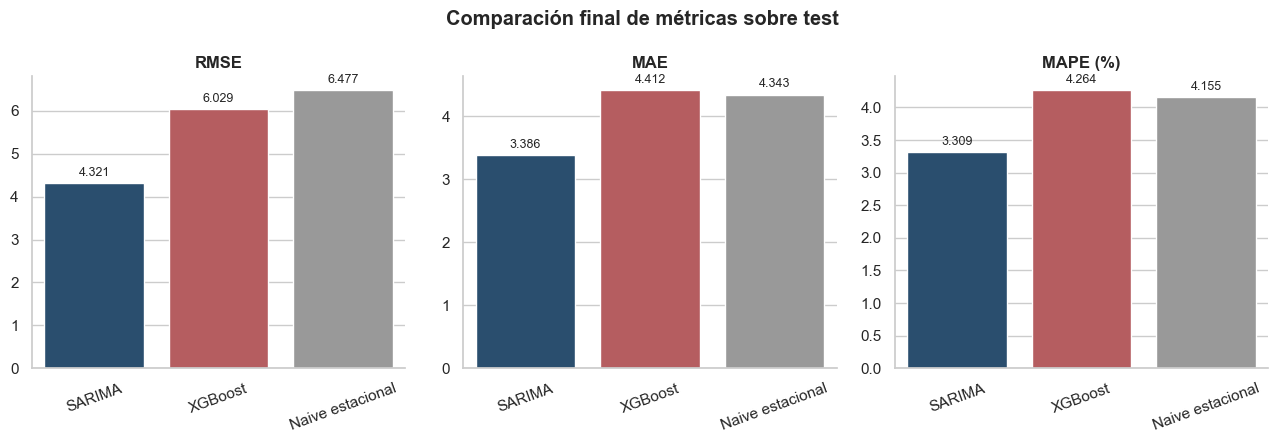

In [18]:
metrics_long = (
    test_model_comparison.reset_index()
    .melt(id_vars='modelo', var_name='métrica', value_name='valor')
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
palette = {'Naive estacional': '#999999', 'SARIMA': '#1f4e79', 'XGBoost': '#c44e52'}
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE_pct']):
    subset = metrics_long[metrics_long['métrica'].eq(metric)]
    sns.barplot(data=subset, x='modelo', y='valor', hue='modelo', palette=palette, legend=False, ax=ax)
    ax.set_title('MAPE (%)' if metric == 'MAPE_pct' else metric)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
fig.suptitle('Comparación final de métricas sobre test', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '14_metricas_test.png', dpi=180, bbox_inches='tight')
plt.show()

## 14. Análisis final de errores

El diagnóstico se realiza sobre SARIMA porque fue el modelo seleccionado antes de abrir test. Con solo 24 errores, las pruebas y gráficos deben interpretarse como evidencia descriptiva y no como una conclusión definitiva sobre su distribución.

,media_error,desviacion_estandar,minimo,maximo
SARIMA,-0.7713,4.3428,-10.8244,9.1163


,lb_stat,lb_pvalue
6,6.4999,0.3696
12,12.8259,0.3818


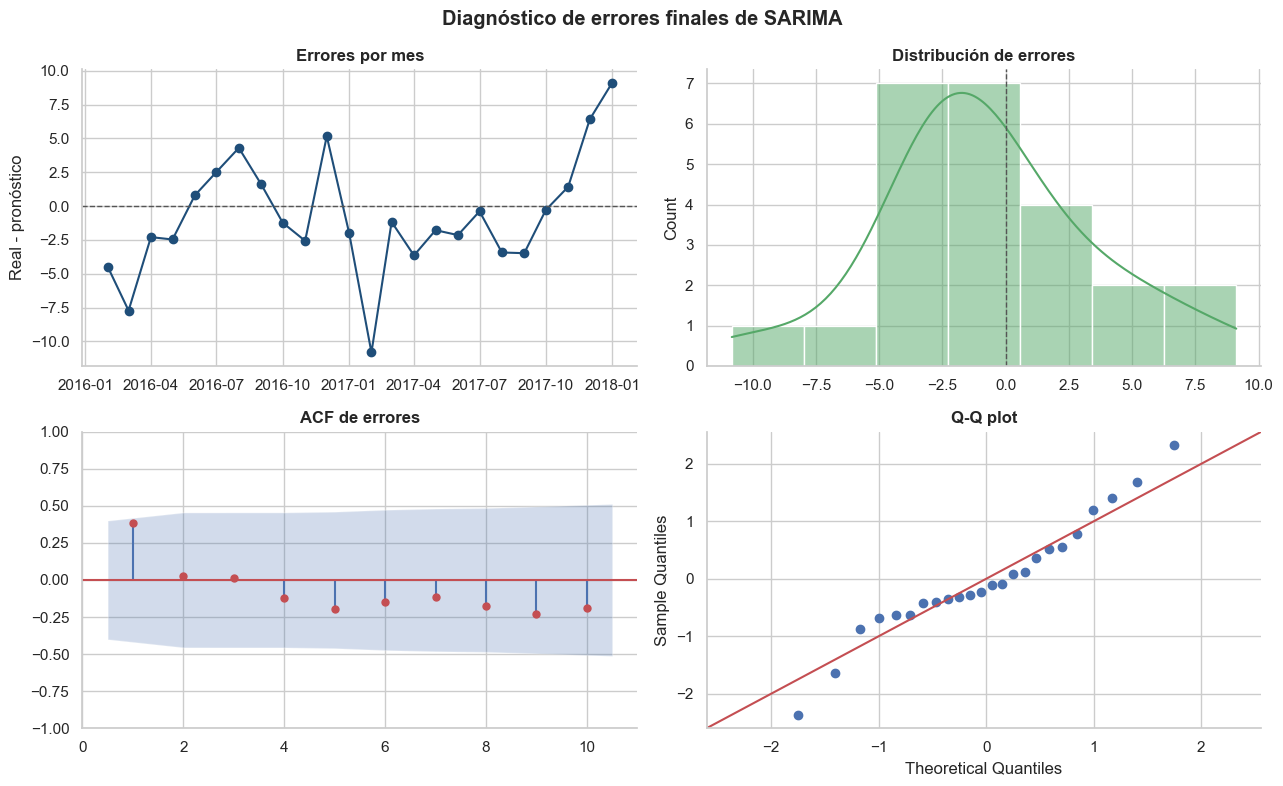

In [19]:
selected_model_name = validation_model_comparison.index[0]
assert selected_model_name == 'SARIMA'
sarima_test_errors = test - sarima_test_forecast
sarima_test_ljung_box = acorr_ljungbox(
    sarima_test_errors, lags=[6, 12], return_df=True
)
test_error_summary = pd.DataFrame({
    'media_error': [sarima_test_errors.mean()],
    'desviacion_estandar': [sarima_test_errors.std(ddof=1)],
    'minimo': [sarima_test_errors.min()],
    'maximo': [sarima_test_errors.max()],
}, index=['SARIMA'])
test_error_summary.to_csv(RESULTS_DIR / 'sarima_test_error_summary.csv')
sarima_test_ljung_box.to_csv(RESULTS_DIR / 'sarima_test_ljung_box.csv')
display(test_error_summary.round(4))
display(sarima_test_ljung_box.round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(sarima_test_errors, marker='o', color='#1f4e79')
axes[0, 0].axhline(0, color='#555555', linestyle='--', linewidth=1)
axes[0, 0].set_title('Errores por mes')
axes[0, 0].set_ylabel('Real - pronóstico')
sns.histplot(sarima_test_errors, kde=True, color='#55a868', ax=axes[0, 1])
axes[0, 1].axvline(0, color='#555555', linestyle='--', linewidth=1)
axes[0, 1].set_title('Distribución de errores')
plot_acf(sarima_test_errors, lags=10, zero=False, color='#c44e52', ax=axes[1, 0])
axes[1, 0].set_title('ACF de errores')
sm.qqplot(sarima_test_errors, line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title('Q-Q plot')
fig.suptitle('Diagnóstico de errores finales de SARIMA', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '15_sarima_errores_test.png', dpi=180, bbox_inches='tight')
plt.show()

## Conclusiones finales

1. SARIMA, elegido previamente en validation, también obtuvo el mejor desempeño en test: RMSE `4,3207`, MAE `3,3861` y MAPE `3,3093 %`.
2. Frente a la referencia estacional, SARIMA redujo RMSE en `33,29 %`, MAE en `22,03 %` y MAPE en `20,35 %`. La mejora consistente en las tres métricas demuestra valor predictivo por encima de una repetición anual simple.
3. XGBoost alcanzó RMSE `6,0292`, MAE `4,4115` y MAPE `4,2640 %`. Mejoró el RMSE del baseline, pero fue ligeramente peor en MAE y MAPE; por lo tanto, no supera de manera consistente a la referencia.
4. SARIMA redujo RMSE en `28,34 %`, MAE en `23,24 %` y MAPE en `22,39 %` respecto de XGBoost. El modelo estadístico representa mejor la estructura estacional regular de esta serie.
5. El error medio de SARIMA fue `-0,7713`, lo que indica una sobreestimación promedio pequeña. Ljung-Box produjo valores p de `0,3696` a 6 meses y `0,3818` a 12 meses, sin evidencia significativa de autocorrelación remanente.
6. Los errores extremos se concentran en algunos picos y valles, incluido el máximo del final de test. El Q-Q plot muestra desvíos moderados en las colas; con solo 24 observaciones, este diagnóstico se interpreta de forma descriptiva.
7. La evaluación de test se utilizó una sola vez y no modificó configuraciones ni criterios de selección. El modelo final recomendado es `SARIMA(2,0,2)(1,1,1,12)` sobre la serie logarítmica.